In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [ ]:
## Cleaned Data

eco_df = pd.read_csv('../datasets/eco_df_clean.csv')


In [19]:
## Raws that are related to Toxoplasmosis only

tox_keywords = [
    'toxoplasma',
    'toxoplasmosis',
    'toxoplasma gondii'
]

df_toxo_eco = eco_df[
    eco_df['Details']
    .str.lower()
    .str.contains('|'.join(tox_keywords), na=False)
]




## Predatiin
predation_keywords = [
    'predation',
    'hunt',
    'hunting',
    'prey',
    'kills',
    'killing',
    'biodiversity',
    'native species',
    'birds',
    'reptiles',
    'mammals'
]

df_prevention_eco = eco_df[
    (eco_df['Type_of_cost_merged'].isin(['Management', 'Prevention'])) &
    (~eco_df['Details']
      .str.lower()
      .str.contains('|'.join(predation_keywords), na=False))
]

## CATS only

cats_only_df = eco_df[
    eco_df['Common_name']
    .astype(str)
    .str.lower()
    .str.contains(r'\bcat\b', na=False) &
    ~eco_df['Common_name'].str.contains(r',|\+|/|;|\band\b', case=False, na=False)
]


## Subset with multispecies
multi_species_df_eco = df_prevention_eco[
    eco_df['Common_name']
    .str.lower()
    .str.contains('cat', na=False) &
    eco_df['Common_name']
    .str.contains(',|\+| and |;', na=False)
]


C:\Users\User\AppData\Local\Temp\ipykernel_10484\1608827279.py:52: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  multi_species_df_eco = df_prevention_eco[


## Cats VS. Cats and someone else

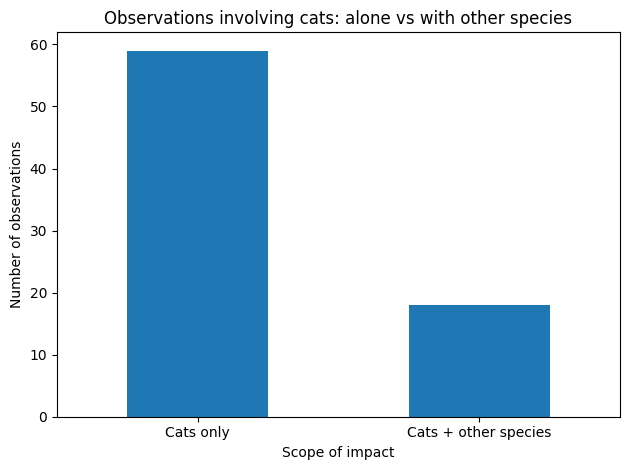

In [ ]:
##  Create scope variable
eco_df['cat_scope'] = eco_df['Common_name'].apply(
    lambda x: 'Cats only'
    if isinstance(x, str) and ',' not in x
    else 'Cats + other species'
)

## Count observations
cat_counts = eco_df['cat_scope'].value_counts()

## Plot
plt.figure()
cat_counts.plot(kind='bar')
plt.title('Observations involving cats: alone vs with other species')
plt.xlabel('Scope of impact')
plt.ylabel('Number of observations')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## Types of Cost

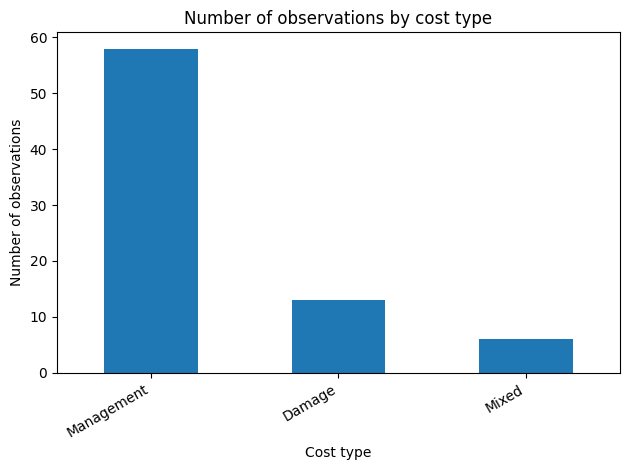

In [16]:
type_counts = eco_df['Type_of_cost_merged'].value_counts()

plt.figure()
type_counts.plot(kind='bar')
plt.title('Number of observations by cost type')
plt.xlabel('Cost type')
plt.ylabel('Number of observations')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## Cost Type: Cats VS. Cats + others...

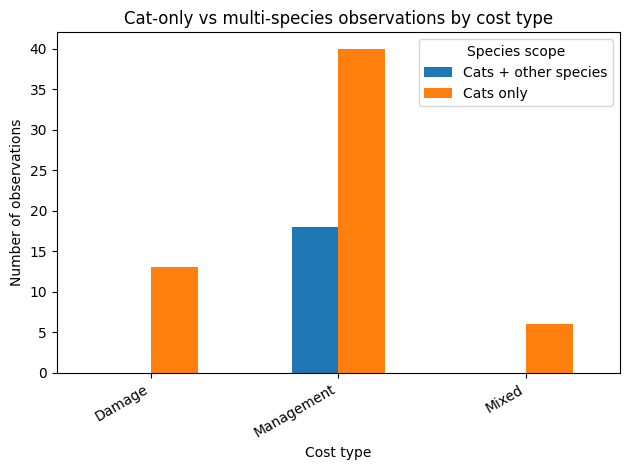

In [20]:
ax = scope_by_type.plot(kind='bar')

ax.legend(
    title='Species scope',
    labels=['Cats + other species', 'Cats only']
)

plt.title('Cat-only vs multi-species observations by cost type')
plt.xlabel('Cost type')
plt.ylabel('Number of observations')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()
